In [12]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

from concurrent.futures import ThreadPoolExecutor
import os

import scipy.linalg as la
import matplotlib.pyplot as plt
from scripts.constants import *
from scripts.hamiltonian_v2_epos import Hamiltonian, Lattice
from scripts.self_consistency_v2_epos import bdg_self_consistency
from scripts.utils import is_hermitian

In [ ]:
X, Y = 10,50
lattice = Lattice(X, Y)

t = 1
mu = -1.8 * t * np.ones(lattice.X)
T = 0.15
U0 = 2 * t
U = U0 * np.ones(lattice.X)
V0 = 1.5 * t 
V = V0 * np.ones(lattice.X)
V_prime = V
H = Hamiltonian(t, mu, lattice,
                U=None, V_prime=None, V=V,
                F_init=[0.1, -0.1, 0.1j, -0.1j])

In [14]:
from scripts.utils import g

print(g(1,2))

6


In [16]:
bdg_self_consistency(H, maxiter=50, atol=1e-3, rtol=0.1, temperature=0.15, verbose=True)

Iteration 1:
F0:
Absolute error: 7.855255998174203e-17
Relative error: 7.855255998174202e-05
Average_old: 0j
Average_new: (9.236047256860891e-18+0j)
F_xplus:
Absolute error: 0.14613619407860745
Relative error: 1.4613619407714606
Average_old: (0.09999999999999999+0j)
Average_new: (0.05163355927570285+0j)
F_xmin:
Absolute error: 0.14613619407860745
Relative error: 1.4613619408006882
Average_old: (-0.09999999999999999+0j)
Average_new: (-0.05163355927570285+0j)
F_yplus:
Absolute error: 0.12358963367598053
Relative error: 1.2358963367598053
Average_old: 0.1j
Average_new: (1.2464259225436481e-17+0.0609417724221816j)
F_ymin:
Absolute error: 0.12358963367598053
Relative error: 1.2358963367598053
Average_old: -0.1j
Average_new: (1.2464259225436481e-17-0.0609417724221816j)
Fuu_xplus:
Absolute error: 1.6450310851358445e-17
Relative error: 1.6450310851358444e-05
Average_old: 0j
Average_new: (-4.626944149452441e-19+0j)
Fuu_xmin:
Absolute error: 9.977216148940166e-18
Relative error: 9.97721614894016

In [ ]:
bdg_self_consistency(H, maxiter=1, atol=1e-4, rtol=0.1, verbose=True) # CHECK: triplet y- and singlet BCS

Iteration 1:
F0:
Absolute error: 4.4562629393171425e-18
Relative error: 4.456268357517496e-06
Average_old: (-2.627383678668075e-19+0j)
Average_new: (2.87064643387963e-19+0j)
F_xplus:
Absolute error: 1.416114536325219e-15
Relative error: 0.0014153717737471142
Average_old: (4.639990805945818e-16+0j)
Average_new: (8.110715593053947e-18+0j)
F_xmin:
Absolute error: 1.4116359943927742e-15
Relative error: 0.001412376234117275
Average_old: (-4.618434113877408e-16+0j)
Average_new: (-8.059339067714382e-18+0j)
F_yplus:
Absolute error: 4.357911904691481e-18
Relative error: 4.357911542836994e-06
Average_old: (1.1361436352993781e-19-2.879387764704892e-19j)
Average_new: (-4.605322576168444e-19+1.3499525996975216e-19j)
F_ymin:
Absolute error: 4.357911904691481e-18
Relative error: 4.357911542836994e-06
Average_old: (1.1361436352993781e-19+2.879387764704892e-19j)
Average_new: (-4.605322576168444e-19-1.3499525996975216e-19j)
Fuu_xplus:
Absolute error: 6.364771510313533e-18
Relative error: 6.3647693223322

In [ ]:
# print(is_hermitian(H.build_Hk(PI/4)))
# print(is_hermitian(H.matrix))
print(np.mean(H.F0))

(2.87064643387963e-19+0j)


In [ ]:
F0, F_xplus, F_xmin, F_yplus, F_ymin,\
Fuu_xplus, Fuu_xmin, Fuu_yplus, Fuu_ymin,\
Fdd_xplus, Fdd_xmin, Fdd_yplus, Fdd_ymin= H.get_correlations()

In [ ]:
Nx = F_yplus.shape[0]  # number of x sites

Fx_p = np.zeros(Nx, dtype=complex)
Fx_m = np.zeros(Nx, dtype=complex)
Fx_p[:-1] = F_xplus
Fx_m[1:]  = F_xmin

Fuux_p = np.zeros(Nx, dtype=complex)
Fuux_m = np.zeros(Nx, dtype=complex)
Fuux_p[:-1] = Fuu_xplus
Fuux_m[1:]  = Fuu_xmin

Fddx_p = np.zeros(Nx, dtype=complex)
Fddx_m = np.zeros(Nx, dtype=complex)
Fddx_p[:-1] = Fdd_xplus
Fddx_m[1:]  = Fdd_xmin

print(np.mean(F0))
print(np.mean(Fx_p - Fx_m)/2)
print(np.mean(F_yplus - F_ymin)/2)
print(np.mean(Fx_p + Fx_m - F_yplus - F_ymin)/4)
print(np.mean(Fx_p + Fx_m + F_yplus + F_ymin)/4)
# U=5.2 : (0.027423485852989458+0j)
# U = 2: (0.017987400064643444+0j) 
# Rest are edges but why not extended s

(2.87064643387963e-19+0j)
(7.276524597345751e-18+0j)
1.3499525996975216e-19j
(2.4182584700982386e-19+0j)
(-2.187064106070205e-19+0j)


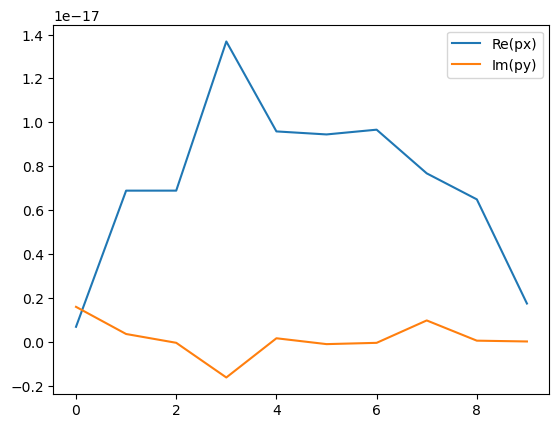

In [ ]:
plt.plot(np.real(Fx_p - Fx_m)/2, label='Re(px)')
# plt.plot(np.real(Fddx_p - Fddx_m)/2, label='Re(px) down-down')
# plt.plot(np.real(Fuux_p - Fuux_m)/2, label='Re(px) up-up')
# plt.plot(np.imag(Fdd_yplus - Fdd_ymin)/2, label='Im(py) down-down')
# plt.plot(np.imag(Fuu_yplus - Fuu_ymin)/2, label='Im(py) up-up')

plt.plot(np.imag(F_yplus - F_ymin)/2, label='Im(py)')
# plt.plot(np.abs(F0), label='on-site')
# plt.plot(np.real(Fx_p + Fx_m - F_yplus - F_ymin)/4, label='d-wave')
# plt.plot(np.real(Fx_p + Fx_m + F_yplus + F_ymin)/4, label='extended-s')
plt.legend()

In [ ]:
energies = np.linspace(-4,7,1000) 
dos_values = H.dos(energies, eta=0.0051)
plt.figure(figsize=(6,4))
plt.plot(energies, dos_values)
plt.ylim(0, None)
plt.xlim(-4,7)
plt.xlabel(r'Energy ($E/t$)', fontsize=16)
plt.ylabel(r'$D(E)$ ($t$ units)', fontsize=16)
# plt.text(2., 0.6, "(a)",fontsize=18, fontweight='bold', va='top', ha='left')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

AttributeError: 'Hamiltonian' object has no attribute 'build_Hk'

In [ ]:
print(H.free_energy(0))